#### UČITAVANJE PAKETA

In [261]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [262]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights

In [263]:
from pathlib import Path
import os
from PIL import Image

In [264]:
from sklearn.manifold import TSNE 

Postavljanje seed-a radi reprodukcije koda.

In [265]:
SEED = 3617

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [266]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEVICE = get_device()

def bind_gpu(data):
    device = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(data_elem) for data_elem in data]
    else:
        return data.to(device, non_blocking=True)

#### UČITAVANJE DATASET-OVA 

Ovaj skup podataka je već podeljen na trening i validacioni skup, pa ćemo ih odvojeno učitati, a test skup ćemo praviti posebno pri modelovanju.

In [267]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
val_dir = base_dir / "val"   

print(train_dir)
print(val_dir)

..\data\tomatoleaf\tomato\train
..\data\tomatoleaf\tomato\val


In [268]:
# Provera da li je dobro ucitano
print(train_dir.exists())
print(val_dir.exists())

True
True


Za transformacije smo izabrali standardnu veličinu slika i standardne, već izračunate vrednosti očekivanja i standardne devijacije za svaki kanal slike.

In [269]:
norm_mean = [0.485, 0.456, 0.406]
norm_stddev = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_stddev)
])

In [270]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)

Sa analizom skupa započinjemo prikazivanjem osnovnih informacija.

In [271]:
print("Klase:", train_dataset.classes)
print("Broj klasa:", len(train_dataset.classes))
print("Broj slika u trening skupu:", len(train_dataset))
print("Broj slika u validacionom skupu:", len(val_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u trening skupu: 10000
Broj slika u validacionom skupu: 1000


In [272]:
train_dataset.class_to_idx  # ovde mozemo videti koji je indeks svake klase

{'Tomato___Bacterial_spot': 0,
 'Tomato___Early_blight': 1,
 'Tomato___Late_blight': 2,
 'Tomato___Leaf_Mold': 3,
 'Tomato___Septoria_leaf_spot': 4,
 'Tomato___Spider_mites Two-spotted_spider_mite': 5,
 'Tomato___Target_Spot': 6,
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7,
 'Tomato___Tomato_mosaic_virus': 8,
 'Tomato___healthy': 9}

In [273]:
train_dataset.samples[0]

('..\\data\\tomatoleaf\\tomato\\train\\Tomato___Bacterial_spot\\00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG',
 0)

#### PRIKAZ SLIKA

Prikazaćemo iz svake klase po jednu sliku kako bismo se bolje upoznali sa samim skupom podataka.

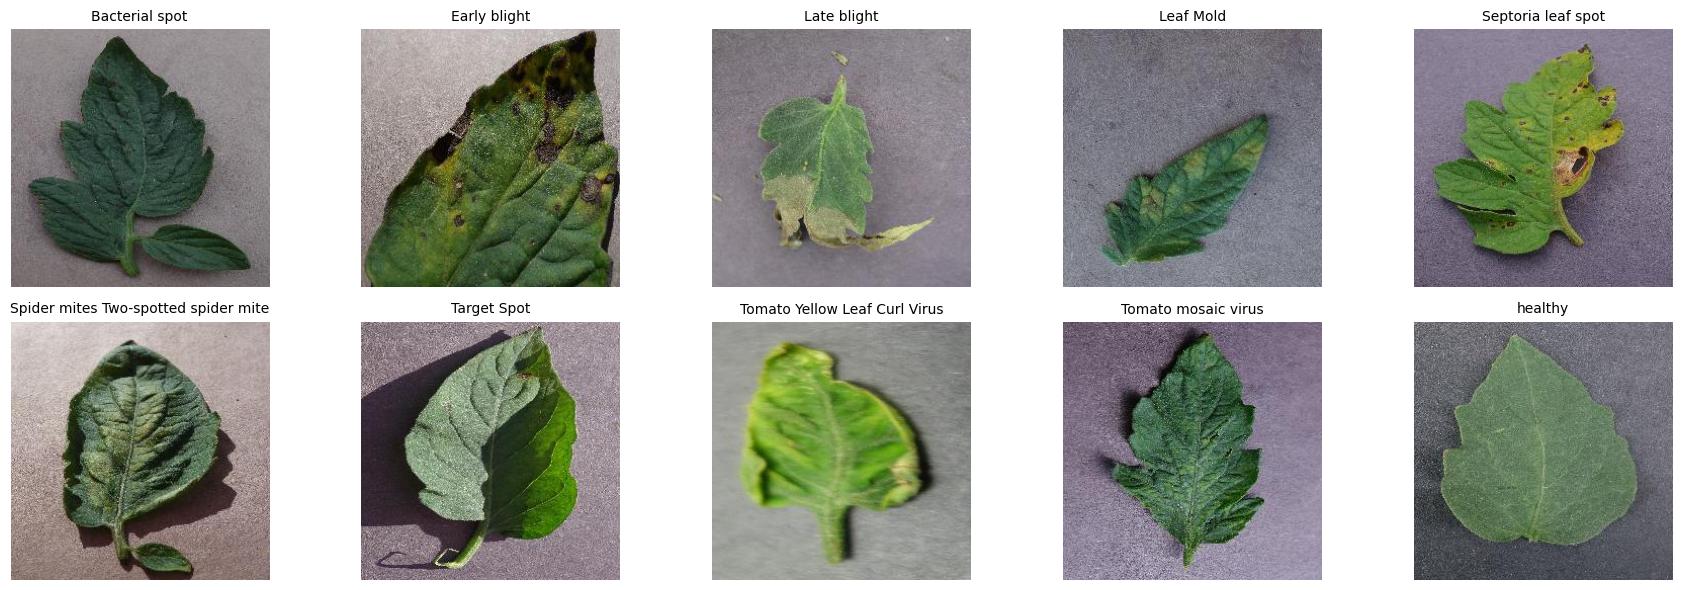

In [274]:
fig, axes = plt.subplots(2, 5, figsize=(18,6))
axes = axes.flatten()

for i, cls in enumerate(train_dataset.classes):
    img_path = list((train_dir / cls).glob("*.jpg"))[0]  # prva slika u klasi
    img = plt.imread(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(cls.replace("Tomato___", "").replace("_", " "), fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Iz narednog koda možemo zaključiti da su sve originalne slike veličine 256x256.

In [275]:
sizes = []

for cls in train_dir.iterdir():
    if cls.is_dir():
        for img_path in list(cls.glob("*"))[:50]:  # uzorak
            img = Image.open(img_path)
            sizes.append(img.size)

sizes = np.array(sizes)

print("Min size:", sizes.min(axis=0))
print("Max size:", sizes.max(axis=0))
print("Avg size:", sizes.mean(axis=0))

Min size: [256 256]
Max size: [256 256]
Avg size: [256. 256.]


Što se tiče transformisanih slika, broj kanala je 3 što svakako odgovara slikama u boji, a veličina je sada promenjena na 224x224.

In [276]:
train_dataset[0][0].shape  

torch.Size([3, 224, 224])

#### ANALIZA BALANSIRANOSTI KLASA

Sada ćemo prikazati broj slika po klasama kako bismo proverili balansiranost podataka.

In [277]:
class_counts = {}

for cls in train_dataset.classes:
    class_dir = train_dir / cls
    class_counts[cls] = len(os.listdir(class_dir))

df = pd.DataFrame(class_counts.items(), columns=["Class", "Count"])
df = df.sort_values(by="Count", ascending=False)

df_display = df.copy()
df_display["Class"] = (
    df_display["Class"]
    .str.replace("Tomato___", "", regex=False)
    .str.replace("_", " ", regex=False)
)

df_display

,Class,Count
0,Bacterial spot,1000
1,Early blight,1000
2,Late blight,1000
3,Leaf Mold,1000
4,Septoria leaf spot,1000
5,Spider mites Two-spotted spider mite,1000
6,Target Spot,1000
7,Tomato Yellow Leaf Curl Virus,1000
8,Tomato mosaic virus,1000
9,healthy,1000


Primecujemo da su nam podaci savrseno balansirani, jer svaka klasa sadrzi isti broj slika.
To mozemo prikazati i graficki.

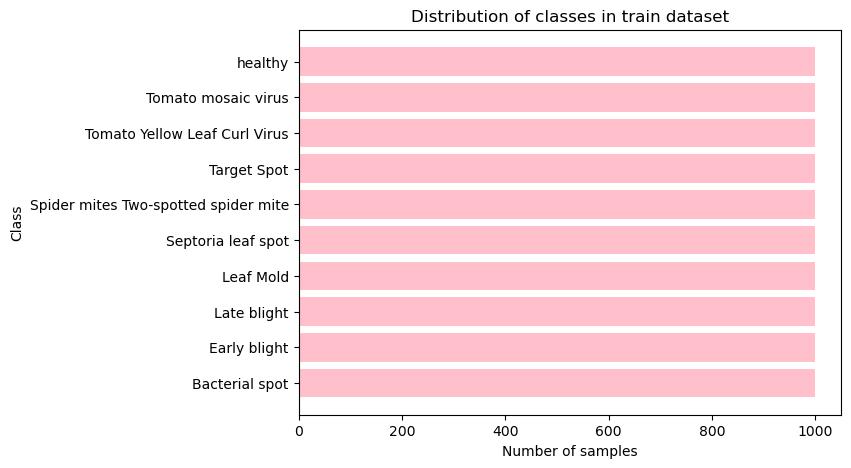

In [278]:
plt.figure(figsize=(7,5))

plt.barh(df_display["Class"], df_display["Count"], color = 'pink')
plt.title("Distribution of classes in train dataset")
plt.xlabel("Number of samples")
plt.ylabel("Class")
plt.show()

#### t-SNE

Za potrebe vizuelne analize koristićemo t-SNE projekciju koja pokazuje raspodelu uzoraka u dvodimenzionalnom prostoru.

Na osnovu nje ćemo videti koliko su nam slike iz različitih klasa slične.

Zarad bržeg izvršavanja, uzećemo uzorak od 100 slika po klasi.

In [279]:
max_per_class = 100

data = []
labels = []

class_counts = {cls: 0 for cls in train_dataset.classes}

for img, label in train_dataset:
    
    cls_name = train_dataset.classes[label]
    
    if class_counts[cls_name] < max_per_class:
        data.append(img.view(-1).numpy())  # flatten
        labels.append(label)
        class_counts[cls_name] += 1

    if all(v >= max_per_class for v in class_counts.values()):
        break

data = np.array(data)
labels = np.array(labels)

print(data.shape)

(1000, 150528)


Vidimo da nam se u uzorku nalazi 1000 slika, što je i očekivano, jer smo uzeli po 100 slika iz svake od 10 klasa.

Druga dimenzija nam zapravo predstavlja veličinu "flattened" slike, koju ćemu proveriti narednim kodom.

In [280]:
224 * 224 * 3

150528

Sada sledi t-SNE redukcija, odnosno "pakovanje" slika u 2D prostor, a potom i vizuelizacija toga.

In [281]:
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30
)

data_2d = tsne.fit_transform(data)

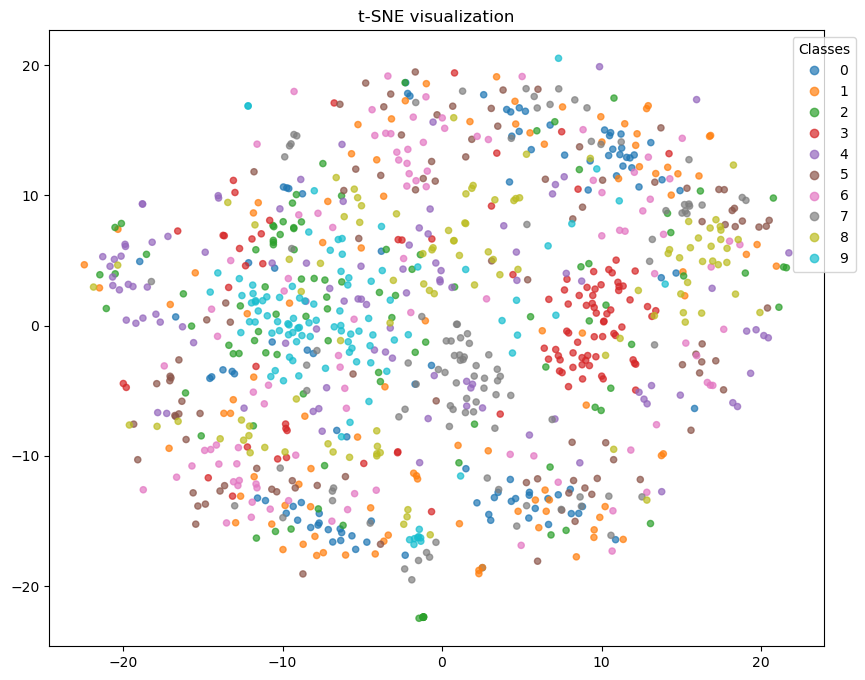

In [282]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    data_2d[:,0],
    data_2d[:,1],
    c=labels,
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05, 1))
plt.title("t-SNE visualization")
plt.show()

t-SNE analiza na sirovim pikselima pokazuje značajno preklapanje klasa, što ukazuje da direktna reprezentacija piksela nije dovoljna za separaciju 
vizuelno sličnih kategorija. To je i očekivano, jer ovakav t-SNE vidi samo osvetljenje, pozadinu i boje, koji su manje-više slični na svim slikama.

Kako bismo dobili klastere koji grupišu bolesti i odvajaju zdrave biljke, koristićemo tzv. CNN feature extractor, npr. ResNet, uz t-SNE.

In [283]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

Vršimo ekstrakciju atributa. Ovo će malo potrajati...

In [284]:
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

In [285]:
features = []
labels = []

feature_extractor = feature_extractor.to(DEVICE)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)

        out = feature_extractor(imgs)   # [B, 512, 1, 1]
        out = out.view(out.size(0), -1) # [B, 512]

        features.append(out.cpu().numpy())
        labels.append(lbls.numpy())

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

print(features.shape)

(10000, 512)


Potom vadimo uzorak i primenjujemo t-SNE na isti način kao i malopre.

In [286]:
max_per_class = 100

selected_features = []
selected_labels = []

count = {i:0 for i in range(len(train_dataset.classes))}

for f, l in zip(features, labels):
    if count[l] < max_per_class:
        selected_features.append(f)
        selected_labels.append(l)
        count[l] += 1

    if all(v >= max_per_class for v in count.values()):
        break

selected_features = np.array(selected_features)
selected_labels = np.array(selected_labels)

print(selected_features.shape)

(1000, 512)


In [287]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

features_2d = tsne.fit_transform(selected_features)

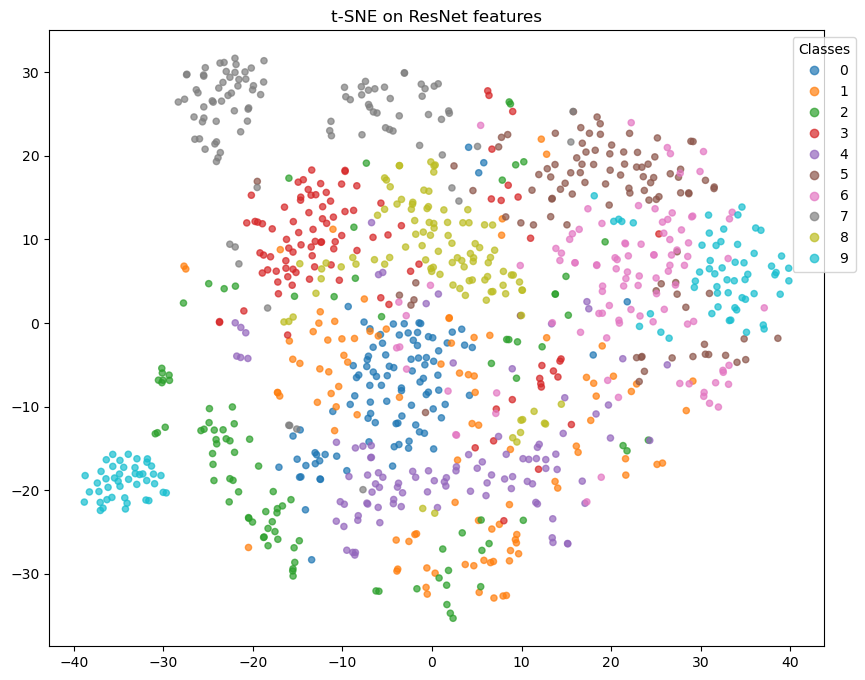

In [288]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    features_2d[:,0],
    features_2d[:,1],
    c=selected_labels,
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05, 1))
plt.title("t-SNE on ResNet features")
plt.show()

Možemo da primetimo da su klase mnogo bolje razdvojene nego malopre, ali i dalje vidimo dosta preklapanja.

To nam ukazuje na to da slike iz različitih klasa dosta liče, u šta možemo da se uverimo i crtanjem pojedinih parova klasa koje se preklapaju.

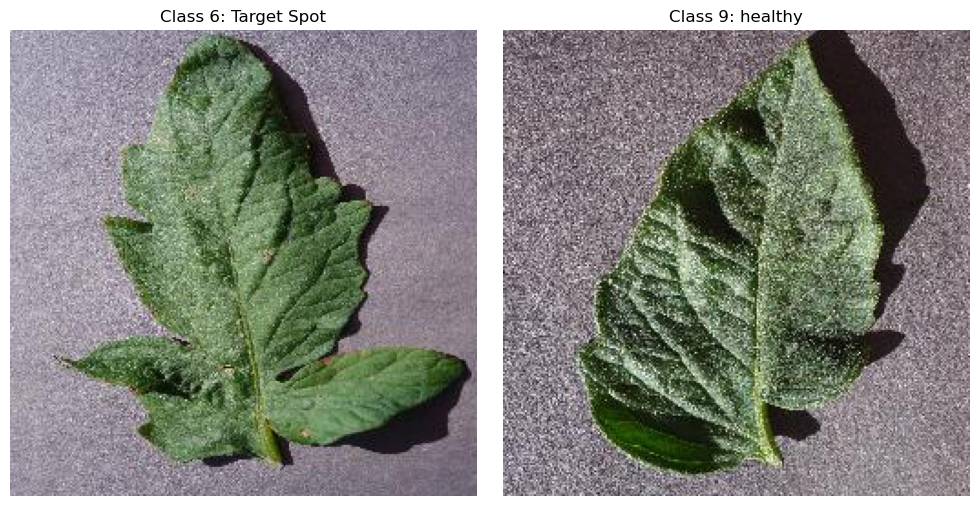

In [289]:
# klase po indeksu
class_6 = train_dataset.classes[6]
class_9 = train_dataset.classes[9]

# uzimamo po jednu sliku iz svake klase, neka to ovog puta bude 6. slika
img6_path = list((train_dir / class_6).glob("*"))[5]  
img9_path = list((train_dir / class_9).glob("*"))[5]

# učitavamo slike
img6 = plt.imread(img6_path)
img9 = plt.imread(img9_path)

# prikaz
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(img6)
axes[0].set_title(f"Class 6: {class_6.replace('Tomato___', '').replace('_', ' ')}")
axes[0].axis("off")

axes[1].imshow(img9)
axes[1].set_title(f"Class 9: {class_9.replace('Tomato___', '').replace('_', ' ')}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

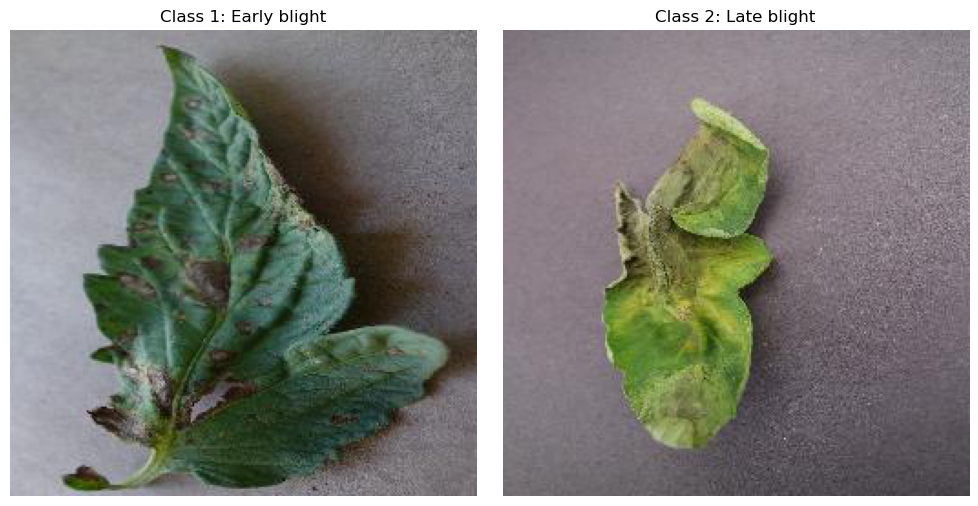

In [290]:
# klase po indeksu
class_1 = train_dataset.classes[1]
class_2 = train_dataset.classes[2]

# uzimamo po jednu sliku iz svake klase, neka to ovog puta bude 26. slika
img1_path = list((train_dir / class_1).glob("*"))[25]  
img2_path = list((train_dir / class_2).glob("*"))[25]

# učitaj slike
img1 = plt.imread(img1_path)
img2 = plt.imread(img2_path)

# prikaz
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(img1)
axes[0].set_title(f"Class 1: {class_1.replace('Tomato___', '').replace('_', ' ')}")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title(f"Class 2: {class_2.replace('Tomato___', '').replace('_', ' ')}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Iz prethodnog stvarno zaključujemo da su slike iz različitih klasa dosta vizuelno slične, što nam otežava klasifikaciju, pa je potrebno
koristiti složenije modele. Takođe, očekujemo da će model praviti najviše grešaka upravo kod klasa koje se najviše preklapaju.